# AIRAC RAD route selection and fuel-optimal trajectory refinement

This example uses a source-derived EUROCONTROL/NM AIRAC 2406 VST subset to select Amsterdam-Rome route candidates, then refines each candidate with wind-aware OpenTOP fuel optimization.

The quick start shows the public API first. The later sections expose parsing, graph construction, screening, route diversity, and NLP handoff.

Original waypoint identifiers, coordinates, ASE segments, and airport records are preserved. This is a development snapshot, not a current operational flight-planning product; complete RAD management-rule, calendar, procedure, and AIRAC-change evaluation remains outside its scope.

In [1]:
import json
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

import numpy as np
import opentop as top
import pandas as pd
from opentop import rad

ROOT = Path.cwd()
if ROOT.name == "examples":
    ROOT = ROOT.parent
DATA = ROOT / "examples" / "data" / "rad_airac2406"

COLORS = ("#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9")
DATA_CRS = ccrs.PlateCarree()
MAP_CRS = ccrs.LambertConformal(central_longitude=9.0, central_latitude=47.0)
MAP_EXTENT = [2.0, 15.5, 40.0, 54.0]
mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
    }
)


def finish_axis(axis, *, grid=True):
    if grid:
        axis.grid(alpha=0.18, linewidth=0.6)
    legend = axis.get_legend()
    if legend is not None:
        legend.set_frame_on(False)


def finish_map(axis, title):
    axis.set_extent(MAP_EXTENT, crs=DATA_CRS)
    axis.add_feature(cfeature.LAND.with_scale("110m"), facecolor="#F4F3EF", zorder=0)
    axis.add_feature(cfeature.OCEAN.with_scale("110m"), facecolor="#EAF2F8", zorder=0)
    axis.coastlines(resolution="110m", linewidth=0.55, color="#555555")
    axis.add_feature(
        cfeature.BORDERS.with_scale("110m"), linewidth=0.45, edgecolor="#777777"
    )
    gridlines = axis.gridlines(
        crs=DATA_CRS,
        draw_labels=True,
        linewidth=0.35,
        color="#777777",
        alpha=0.45,
        linestyle=":",
        x_inline=False,
        y_inline=False,
    )
    gridlines.top_labels = False
    gridlines.right_labels = False
    gridlines.xlabel_style = {"size": 7}
    gridlines.ylabel_style = {"size": 7}
    axis.set_title(title)
    legend = axis.get_legend()
    if legend is not None:
        legend.set_frame_on(False)


def add_panel_labels(axes):
    for label, axis in zip("ABCDEFGHIJKLMNOPQRSTUVWXYZ", np.ravel(axes)):
        axis.text(
            -0.16,
            1.06,
            label,
            transform=axis.transAxes,
            fontweight="bold",
            fontsize=11,
            va="top",
        )


from opentop.plotting import (  # noqa: E402
    LINE_STYLES,
    MARKERS,
    apply_publication_style,
    plot_wind_vectors,
    style_map,
)

apply_publication_style()

## Quick start: select and optimize a RAD route

The public workflow has one source-specific step and one shared optimization step:

1. `RadDataset.select_routes(...)` applies RAD context, graph search, and diversity filtering.
2. `top.optimize_routes(...)` performs the continuous fuel optimization used by every route source.

The example uses `Cruise`; FL350 selects the applicable RAD orientation but does not fix OpenTOP's altitude state. The FastMeteo cell is shown explicitly before the optimizer configuration.

In [2]:
example_schema = rad.AseCodeSchema(
    "airac-2406-vst-odd",
    "1",
    {
        code: rad.AseSemantics(
            rad.EdgeDirection.FORWARD,
            metadata={"flight_level_parity": "odd"},
        )
        for code in ((0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 1, 41), (0, 1, 42))
    },
)

### Reproducible ERA5 wind

Every RAD candidate uses the same wind field. `build_route_wind_sample.py` holds the shared FastMeteo request and ERA5 conversion. The cell below loads its checked-in output by default; set `REFRESH_FASTMETEO = True` to refresh the data through FastMeteo.

In [3]:
from runpy import run_path

WIND_HELPER = ROOT / "examples" / "data" / "build_route_wind_sample.py"
REFRESH_FASTMETEO = False

load_fastmeteo_wind_sample = run_path(str(WIND_HELPER))["load_fastmeteo_wind_sample"]
wind = load_fastmeteo_wind_sample(refresh=REFRESH_FASTMETEO)
print(f"Loaded {len(wind):,} FastMeteo/ERA5 wind samples")

Loaded 2,688 FastMeteo/ERA5 wind samples


In [4]:
dataset = rad.RadDataset.from_ase_files(
    DATA / "airac2406_vst_subset.nnpt",
    DATA / "airac2406_vst_subset.ase",
    DATA / "airac2406_airports.arp",
    schema=example_schema,
    layer="vst",
)
flight = rad.FlightContext(
    "EHAM",
    "LIRF",
    requested_flight_level=350,
    enabled_layers=frozenset({"vst"}),
)

In [5]:
route_selection = rad.RouteSelectionConfig(
    candidates=5,
    search_candidates=100,
    max_cost_ratio=1.50,
    max_distance_ratio=1.60,
    maximum_shared_edge_fraction=0.70,
    budget=rad.SearchBudget(max_expansions=1_000_000),
)
nominal_fuel = rad.NominalFuelCost(
    true_airspeed_mps=230.0,
    fuel_flow_kg_s=1.0,
)
origin = dataset.airports[flight.departure]
destination = dataset.airports[flight.arrival]


def make_optimizer():
    optimizer = top.Cruise(
        "A320",
        (origin.latitude, origin.longitude),
        (destination.latitude, destination.longitude),
        m0=0.85,
    )
    optimizer.enable_wind(wind)
    return optimizer


route_optimization = top.RouteOptimizationConfig(
    objective="fuel",
    waypoint_tolerance_m=15_000.0,
    minimum_nodes=20,
    nodes_per_leg=1,
    waypoint_simplification_tolerance_m=15_000.0,
    trajectory_kwargs={"h_min": 9_000.0, "h_max": 11_000.0},
)

In [6]:
rad_selection = dataset.select_routes(
    flight,
    edge_cost=nominal_fuel,
    config=route_selection,
    connector_count=12,
    maximum_connector_distance_m=300_000.0,
)
route_result = top.optimize_routes(
    rad_selection.options,
    make_optimizer,
    config=route_optimization,
)

### Wind field used by the optimization

Blue arrows show the ERA5 vector field at FL350. The minimum-fuel RAD candidate is orange and the other optimized candidates are gray. The 20 m/s reference makes vector length directly interpretable.

Text(0.5, 1.0, 'ERA5 wind at FL350 and optimized route: RAD route 1 - 1 May 2021, 08:00 UTC')

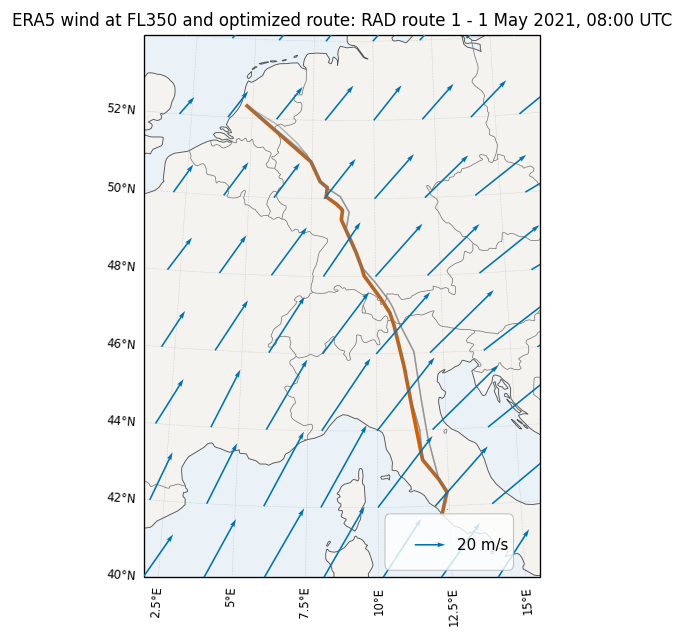

In [7]:
snapshot = wind.query("h == 10668 and ts == 0")

fig = plt.figure(figsize=(9.0, 5.2), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=MAP_CRS)
style_map(ax, extent=MAP_EXTENT, data_crs=DATA_CRS, resolution="50m")

for result in route_result.successful:
    route_lats, route_lons = zip(*result.route.waypoints)
    color = "#D55E00" if result is route_result.best else "#777777"
    width = 2.2 if result is route_result.best else 0.9
    alpha = 1.0 if result is route_result.best else 0.5
    ax.plot(
        route_lons,
        route_lats,
        color=color,
        linewidth=width,
        alpha=alpha,
        transform=DATA_CRS,
        zorder=3,
    )

plot_wind_vectors(
    ax,
    snapshot,
    data_crs=DATA_CRS if "DATA_CRS" in globals() else ccrs.PlateCarree(),
    scale=260,
    width=0.004,
    key_x=0.76,
)
ax.set_title(
    f"ERA5 wind at FL350 and optimized route: {route_result.best.route.name} - "
    "1 May 2021, 08:00 UTC"
)

,candidate,distance_km,screening_score_kg,optimized_fuel_kg,solve_time_s,success,selected
0,1,1362.0,5921.6,4521.1,6.8,True,True
1,2,1362.2,5922.6,4534.4,7.7,True,False
2,3,1364.9,5934.5,4530.7,9.2,True,False
3,4,1365.4,5936.7,4544.3,11.0,True,False
4,5,1366.1,5939.8,4524.3,13.4,True,False


Selected RAD waypoint sequence:
  airport:EHAM:departure → TANJO → *EDHI → *OXPA → *MIVC → ROLIS → ETARU → RUDUS → NOKDI → UBENO → GIGET → ABUKA → SUNEG → KOVAN → TEDGO → UTABA → BATUB → OSDOV → MADEB → TIRUL → NATAG → LORLO → UNTAD → NEGIK → ADOSA → OSTEG → BENUS → KREVA → BOA → OMAKU → AMTEL → UPONO → RITEB → LIGBU → airport:LIRF:arrival


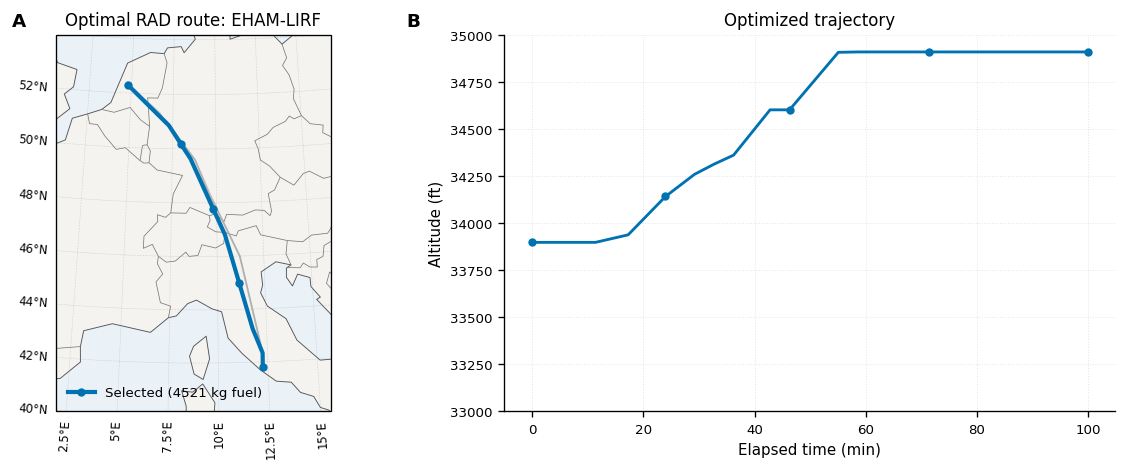

In [8]:
best = route_result.best
assert best is not None and best.trajectory is not None
assert route_result.optimal_route is best.route
assert route_result.trajectory is best.trajectory

quick_table = pd.DataFrame(
    [
        {
            "candidate": index + 1,
            "distance_km": route.distance_m / 1000,
            "screening_score_kg": route.cost,
            "optimized_fuel_kg": optimized.fuel_kg,
            "solve_time_s": route_result.solve_seconds[index],
            "success": optimized.success,
            "selected": optimized is best,
        }
        for index, (route, optimized) in enumerate(
            zip(rad_selection.candidates, route_result.optimized, strict=True)
        )
    ]
)
display(quick_table.round(1))
print("Selected RAD waypoint sequence:")
print("  " + " → ".join(best.route.metadata["node_ids"]))

fig = plt.figure(figsize=(10.5, 4.0))
axes = np.array(
    [fig.add_subplot(1, 2, 1, projection=MAP_CRS), fig.add_subplot(1, 2, 2)]
)
for result in route_result.optimized:
    if result.trajectory is None or result is best:
        continue
    axes[0].plot(
        result.trajectory.longitude,
        result.trajectory.latitude,
        color="#AAAAAA",
        linewidth=1.0,
        alpha=0.7,
        transform=DATA_CRS,
    )
trajectory = route_result.trajectory
axes[0].plot(
    trajectory.longitude,
    trajectory.latitude,
    color=COLORS[0],
    linewidth=2.5,
    marker="o",
    markevery=5,
    markersize=4,
    label=f"Selected ({best.fuel_kg:.0f} kg fuel)",
    transform=DATA_CRS,
)
axes[0].legend(loc="lower left")
finish_map(axes[0], "Optimal RAD route: EHAM-LIRF")

axes[1].plot(
    trajectory.ts / 60,
    trajectory.altitude,
    color=COLORS[0],
    marker="o",
    markevery=5,
    markersize=4,
)
axes[1].set(
    title="Optimized trajectory",
    xlabel="Elapsed time (min)",
    ylabel="Altitude (ft)",
    ylim=(33_000, 35_000),
)
finish_axis(axes[1])
add_panel_labels(axes)
fig.tight_layout()
plt.show()

# Implementation internals

The remaining sections reconstruct the source-specific call one stage at a time. They are useful when integrating another RAD export or tuning search controls. The stored trajectories are reused; the NLPs are not solved twice.

## 1. Inspect the source-derived AIRAC files

The checked-in snapshot was extracted from `NavPoint_2406.nnpt`, `VST_2406.ase`, and `VST_2406_Airports.arp`. It contains the union of five diverse EHAM–LIRF paths found in the full VST graph. The manifest records source-file hashes, extraction settings, and record counts; `build_subset.py` reproduces it when the full export is available under `tmp/rad_data`.

In [9]:
input_files = {
    "Navigation points (NNPT)": DATA / "airac2406_vst_subset.nnpt",
    "VST segments (ASE)": DATA / "airac2406_vst_subset.ase",
    "Airport reference points (ARP)": DATA / "airac2406_airports.arp",
}
manifest = json.loads((DATA / "manifest.json").read_text())
display(
    pd.DataFrame(
        [
            {
                "AIRAC cycle": manifest["airac_cycle"],
                "case": manifest["case"],
                **manifest["records"],
            }
        ]
    )
)

inventory = pd.DataFrame(
    [
        {
            "input": label,
            "file": path.name,
            "size_bytes": path.stat().st_size,
            "nonempty_lines": sum(
                bool(line.strip()) for line in path.read_text().splitlines()
            ),
        }
        for label, path in input_files.items()
    ]
)
display(inventory)

for label, path in input_files.items():
    lines = [line for line in path.read_text().splitlines() if line.strip()]
    print(f"{label}: {path.name}")
    for line in lines[:3]:
        print(f"  {line}")
    print()

,AIRAC cycle,case,navpoints,segments,airports
0,2406,EHAM-LIRF at FL350,100,106,2


,input,file,size_bytes,nonempty_lines
0,Navigation points (NNPT),airac2406_vst_subset.nnpt,3843,101
1,VST segments (ASE),airac2406_vst_subset.ase,6771,106
2,Airport reference points (ARP),airac2406_airports.arp,74,2


Navigation points (NNPT): airac2406_vst_subset.nnpt
  100
  *EDHI;DB;50.8561111111;7.5069444444;_
  *EKAT;DB;49.3391666667;8.9027777833;_

VST segments (ASE): airac2406_vst_subset.ase
  0 1 2 3051.366667 450.416667 3041.266667 458.100000 *EDHI_*OXPA
  0 1 2 2960.350000 534.166667 2951.916667 531.850000 *EKAT_SUNEG
  0 1 2 3033.700000 463.816667 3026.100000 469.516667 *MIVC_ROLIS

Airport reference points (ARP): airac2406_airports.arp
  EHAM 3138.483333 285.850000 EHAA_FIR
  LIRF 2508.016667 734.333333 LIRR_FIR



## 2. Parse and normalize the source records

The NNPT reader resolves named navigation points, ASE preserves segment metadata and arc-minute endpoint coordinates losslessly, and ARP converts airport coordinates from arc-minutes to degrees. Every normalized record retains its source path, original line, and line number. Readers report `valid`, `invalid`, or `indeterminate` instead of silently repairing unknown data.

In [10]:
navpoints = rad.read_nnpt(input_files["Navigation points (NNPT)"])
ase_segments = rad.read_ase(
    input_files["VST segments (ASE)"], navpoints.records, layer="vst"
)
airports = rad.read_arp(input_files["Airport reference points (ARP)"])

parse_summary = pd.DataFrame(
    [
        {
            "dataset": name,
            "records": len(result.records),
            "diagnostics": len(result.diagnostics),
            "status": result.status.value,
        }
        for name, result in (
            ("NNPT", navpoints),
            ("ASE", ase_segments),
            ("ARP", airports),
        )
    ]
)
display(parse_summary)

point_table = pd.DataFrame(
    [
        {
            "point_id": point.point_id,
            "type": point.point_type,
            "latitude_deg": point.latitude,
            "longitude_deg": point.longitude,
            "source": f"{point.provenance.path.name}:{point.provenance.line_number}",
        }
        for point in navpoints.records
    ]
)
print(f"Showing 10 of {len(point_table)} preserved navigation points")
display(point_table.head(10))

airport_table = pd.DataFrame(
    [
        {
            "ICAO": airport.icao,
            "latitude_deg": airport.latitude,
            "longitude_deg": airport.longitude,
            "FIR": airport.fir_id,
        }
        for airport in airports.records
    ]
)
display(airport_table)

,dataset,records,diagnostics,status
0,NNPT,100,0,valid
1,ASE,106,0,valid
2,ARP,2,0,valid


Showing 10 of 100 preserved navigation points


,point_id,type,latitude_deg,longitude_deg,source
0,*EDHI,DB,50.856111,7.506944,airac2406_vst_subset.nnpt:2
1,*EKAT,DB,49.339167,8.902778,airac2406_vst_subset.nnpt:3
2,*MIVC,DB,50.561667,7.730278,airac2406_vst_subset.nnpt:4
3,*OXPA,DB,50.687778,7.635000,airac2406_vst_subset.nnpt:5
4,*RF4,DB,42.423611,12.241667,airac2406_vst_subset.nnpt:6
5,*RF44,DB,42.321111,11.788611,airac2406_vst_subset.nnpt:7
6,*RF46,DB,42.356667,11.938611,airac2406_vst_subset.nnpt:8
7,*RF64,DB,42.388611,12.091111,airac2406_vst_subset.nnpt:9
8,ABUKA,DB,49.465278,8.679167,airac2406_vst_subset.nnpt:10
9,ADOSA,DB,45.644444,11.026389,airac2406_vst_subset.nnpt:11


,ICAO,latitude_deg,longitude_deg,FIR
0,EHAM,52.308056,4.764167,EHAA_FIR
1,LIRF,41.800278,12.238889,LIRR_FIR


### Inspect the actual ASE segment records

Each AIRAC segment has three integer metadata fields, four endpoint coordinates in arc-minutes, and an endpoint token. The source management export identifies the included records as odd-flight-level orientations. Because the example fixes FL350, only those source orientations were extracted; meanings are not extrapolated to other integer codes or flight contexts.

In [11]:
ase_table = pd.DataFrame(
    [
        {
            "source": segment.source_id,
            "target": segment.target_id,
            "raw_fields": segment.raw_fields,
            "source_latitude_deg": segment.source_latitude,
            "source_longitude_deg": segment.source_longitude,
            "target_latitude_deg": segment.target_latitude,
            "target_longitude_deg": segment.target_longitude,
            "source_line": segment.provenance.line_number,
        }
        for segment in ase_segments.records
    ]
)
print(f"ASE parse status: {ase_segments.status.value}")
print(f"Showing 8 of {len(ase_table)} preserved VST segments")
display(ase_table.head(8))
code_counts = (
    ase_table.groupby("raw_fields", as_index=False)
    .size()
    .rename(columns={"size": "segment_count"})
)
display(code_counts)

ASE parse status: valid
Showing 8 of 106 preserved VST segments


,source,target,raw_fields,source_latitude_deg,source_longitude_deg,target_latitude_deg,target_longitude_deg,source_line
0,*EDHI,*OXPA,"(0, 1, 2)",50.856111,7.506944,50.687778,7.635000,1
1,*EKAT,SUNEG,"(0, 1, 2)",49.339167,8.902778,49.198611,8.864167,2
2,*MIVC,ROLIS,"(0, 1, 2)",50.561667,7.730278,50.435000,7.825278,3
3,*OXPA,*MIVC,"(0, 1, 2)",50.687778,7.635000,50.561667,7.730278,4
4,*RF44,*RF46,"(0, 1, 2)",42.321111,11.788611,42.356667,11.938611,5
5,*RF46,SUVOK,"(0, 1, 2)",42.356667,11.938611,42.118333,12.040278,6
6,*RF4,*RF64,"(0, 1, 2)",42.423611,12.241667,42.388611,12.091111,7
7,*RF64,EXAMA,"(0, 1, 2)",42.388611,12.091111,42.150000,12.192222,8


,raw_fields,segment_count
0,"(0, 1, 1)",49
1,"(0, 1, 2)",30
2,"(0, 1, 3)",4
3,"(0, 1, 41)",20
4,"(0, 1, 42)",3


## 3. Apply the fixed-context ASE schema and build the graph

`AseCodeSchema` makes the interpretation explicit and versioned. For this FL350 snapshot, every included odd-oriented segment is used in its recorded source-to-target orientation. Unknown codes would fail closed. Graph edges retain their original ASE code triple and provenance, while parallel links remain distinct.

In [12]:
schema_codes = sorted({segment.raw_fields for segment in ase_segments.records})
assert all(segment.raw_field_2 == 1 for segment in ase_segments.records)
ase_schema = rad.AseCodeSchema(
    "airac-2406-vst-odd",
    "1",
    {
        code: rad.AseSemantics(
            rad.EdgeDirection.FORWARD, metadata={"flight_level_parity": "odd"}
        )
        for code in schema_codes
    },
)
network = rad.graph_from_ase(ase_segments.records, navpoints.records, decode=ase_schema)
edge_table = pd.DataFrame(
    [
        {
            "source": edge.source,
            "target": edge.target,
            "raw_fields": edge.metadata["ase_raw_fields"],
            "distance_km": edge.distance_m / 1000,
            "layer": edge.layer,
            "source_line": edge.provenance.line_number,
        }
        for edge in network.edges.values()
    ]
).sort_values(["source", "target"])
print(
    f"Schema: {ase_schema.schema_id}; graph nodes: {len(network.nodes)}; "
    f"directed edges: {len(network.edges)}"
)
display(edge_table.head(10).round({"distance_km": 1}))

Schema: airac-2406-vst-odd:1; graph nodes: 100; directed edges: 106


,source,target,raw_fields,distance_km,layer,source_line
0,*EDHI,*OXPA,"(0, 1, 2)",20.8,vst,1
1,*EKAT,SUNEG,"(0, 1, 2)",15.9,vst,2
2,*MIVC,ROLIS,"(0, 1, 2)",15.6,vst,3
3,*OXPA,*MIVC,"(0, 1, 2)",15.6,vst,4
6,*RF4,*RF64,"(0, 1, 2)",13.0,vst,7
4,*RF44,*RF46,"(0, 1, 2)",13.0,vst,5
5,*RF46,SUVOK,"(0, 1, 2)",27.8,vst,6
7,*RF64,EXAMA,"(0, 1, 2)",27.8,vst,8
8,ABUKA,SUNEG,"(0, 1, 1)",32.6,vst,9
9,ADOSA,OSTEG,"(0, 1, 1)",52.5,vst,10


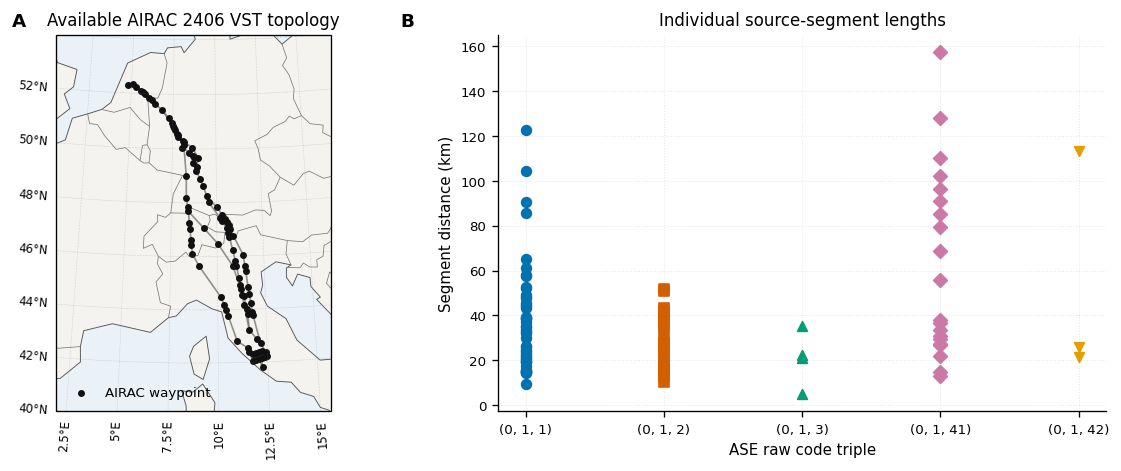

In [13]:
fig = plt.figure(figsize=(10.5, 4.0))
axes = np.array(
    [fig.add_subplot(1, 2, 1, projection=MAP_CRS), fig.add_subplot(1, 2, 2)]
)
for edge in network.edges.values():
    source, target = network.nodes[edge.source], network.nodes[edge.target]
    axes[0].plot(
        [source.longitude, target.longitude],
        [source.latitude, target.latitude],
        color="#777777",
        linewidth=1.0,
        alpha=0.8,
        transform=DATA_CRS,
        zorder=1,
    )
axes[0].scatter(
    [node.longitude for node in network.nodes.values()],
    [node.latitude for node in network.nodes.values()],
    s=10,
    color="#111111",
    label="AIRAC waypoint",
    transform=DATA_CRS,
    zorder=2,
)
axes[0].legend(loc="lower left")
finish_map(axes[0], "Available AIRAC 2406 VST topology")

for index, code in enumerate(schema_codes):
    values = edge_table.loc[edge_table.raw_fields == code, "distance_km"].to_numpy()
    axes[1].scatter(
        np.full(len(values), index),
        values,
        color=COLORS[index % len(COLORS)],
        marker=MARKERS[index % len(MARKERS)],
        s=34,
    )
axes[1].set(
    title="Individual source-segment lengths",
    xlabel="ASE raw code triple",
    ylabel="Segment distance (km)",
    xticks=range(len(schema_codes)),
    xticklabels=[str(code) for code in schema_codes],
)
finish_axis(axes[1])
add_panel_labels(axes)
fig.tight_layout()
plt.show()

## 4. Fix the flight context and connect the airports

The example fixes EHAM–LIRF at FL350, matching the odd-oriented VST snapshot. A reusable network is first filtered by its enabled layer. Directional connectors then run from the departure airport into its nearest retained network point and from the nearest arrival-side point into the destination airport.

In [14]:
context = rad.FlightContext(
    "EHAM",
    "LIRF",
    requested_flight_level=350,
    enabled_layers=frozenset({"vst"}),
)
display(
    pd.DataFrame(
        [
            {
                "departure": context.departure,
                "arrival": context.arrival,
                "requested_flight_level": context.requested_flight_level,
                "level_orientation": "odd",
                "enabled_layers": sorted(context.enabled_layers),
                "ASE schema": ase_schema.schema_id,
            }
        ]
    )
)

,departure,arrival,requested_flight_level,level_orientation,enabled_layers,ASE schema
0,EHAM,LIRF,350,odd,[vst],airac-2406-vst-odd:1


The source-derived subset is deliberately scoped to topology and the fixed FL350 orientation. It does **not** claim that every full AIRAC 2406 AWK/FLC2 restriction, calendar condition, SID/STAR connection, or later AIRAC amendment has been evaluated. Production use must run those conformance stages against the complete applicable dataset rather than treating this documentation snapshot as an operational route authority.

In [15]:
airport_by_icao = rad.airport_index(airports.records)
applicable_network = rad.flight_graph(network, context)
flight_network, source_node, target_node = rad.add_airport_connectors(
    applicable_network,
    airport_by_icao[context.departure],
    airport_by_icao[context.arrival],
    connector_count=12,
    maximum_distance_m=300_000.0,
)
connector_table = pd.DataFrame(
    [
        {
            "source": edge.source,
            "target": edge.target,
            "physical_distance_km": edge.metadata["physical_distance_m"] / 1000,
        }
        for edge in flight_network.edges.values()
        if edge.layer == "connector"
    ]
)
display(
    pd.DataFrame(
        {
            "stage": ["base graph", "context-filtered graph", "connected graph"],
            "nodes": [
                len(network.nodes),
                len(applicable_network.nodes),
                len(flight_network.nodes),
            ],
            "edges": [
                len(network.edges),
                len(applicable_network.edges),
                len(flight_network.edges),
            ],
        }
    )
)
display(connector_table.round({"physical_distance_km": 1}))

,stage,nodes,edges
0,base graph,100,106
1,context-filtered graph,100,106
2,connected graph,102,130


,source,target,physical_distance_km
0,airport:EHAM:departure,AMS.D,0.4
1,airport:EHAM:departure,PAM,22.6
2,airport:EHAM:departure,IVLUT,34.4
3,airport:EHAM:departure,LUNIX,59.0
4,airport:EHAM:departure,RENDI,68.1
5,airport:EHAM:departure,EDUPO,82.2
6,airport:EHAM:departure,NAPRO,102.0
7,airport:EHAM:departure,DEPAD,116.6
8,airport:EHAM:departure,AMOSU,138.0
9,airport:EHAM:departure,MISGO,176.8


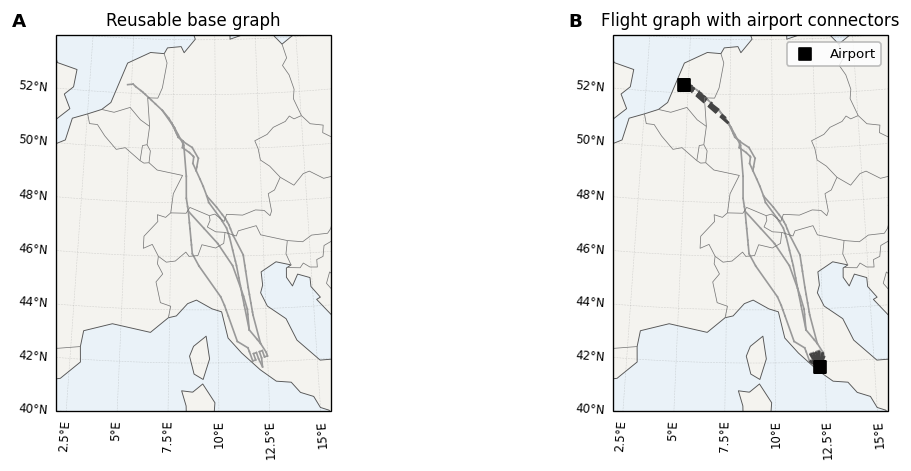

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), subplot_kw={"projection": MAP_CRS})
for axis, graph, title in (
    (axes[0], network, "Reusable base graph"),
    (axes[1], flight_network, "Flight graph with airport connectors"),
):
    for edge in graph.edges.values():
        source = graph.nodes[edge.source]
        target = graph.nodes[edge.target]
        connector = edge.layer == "connector"
        axis.plot(
            [source.longitude, target.longitude],
            [source.latitude, target.latitude],
            color="#444444" if connector else "#999999",
            linestyle="--" if connector else "-",
            linewidth=1.8 if connector else 1.0,
            zorder=1,
            transform=DATA_CRS,
        )
    airport_nodes = [
        node for node in graph.nodes.values() if node.point_type == "AIRPORT"
    ]
    if airport_nodes:
        axis.scatter(
            [node.longitude for node in airport_nodes],
            [node.latitude for node in airport_nodes],
            marker="s",
            s=55,
            color="#000000",
            label="Airport",
            zorder=3,
            transform=DATA_CRS,
        )
    finish_map(axis, title)
axes[1].legend()
add_panel_labels(axes)
fig.tight_layout()
plt.show()

## 5. Calculate the cheap screening cost

Evaluating OpenAP at every graph expansion would be expensive, so `NominalFuelCost` approximates fuel from distance, nominal TAS, optional along-track wind, and a penalty callback. Here the screening cost is deliberately wind-neutral to keep the graph ranking easy to inspect. The final `top.optimize_routes()` solves are authoritative and all use the FastMeteo/ERA5 wind field.

In [17]:
nominal_tas_mps = 230.0
nominal_fuel_flow_kg_s = 1.0
screening_cost = rad.NominalFuelCost(
    true_airspeed_mps=nominal_tas_mps,
    fuel_flow_kg_s=nominal_fuel_flow_kg_s,
)
edge_cost_table = pd.DataFrame(
    [
        {
            "source": edge.source,
            "target": edge.target,
            "layer": edge.layer,
            "distance_km": edge.distance_m / 1000,
            "nominal_time_min": edge.distance_m / nominal_tas_mps / 60,
            "nominal_fuel_kg": screening_cost(edge),
        }
        for edge in flight_network.edges.values()
    ]
)
display(
    edge_cost_table.groupby("layer", as_index=False)
    .agg(
        edges=("source", "size"),
        total_distance_km=("distance_km", "sum"),
        total_nominal_fuel_kg=("nominal_fuel_kg", "sum"),
    )
    .round(1)
)
print("Representative edge costs")
display(edge_cost_table.head(8).round(1))

,layer,edges,total_distance_km,total_nominal_fuel_kg
0,connector,24,1860.2,8087.7
1,vst,106,4175.8,18155.6


Representative edge costs


,source,target,layer,distance_km,nominal_time_min,nominal_fuel_kg
0,*EDHI,*OXPA,vst,20.8,1.5,90.4
1,*EKAT,SUNEG,vst,15.9,1.2,69.1
2,*MIVC,ROLIS,vst,15.6,1.1,67.9
3,*OXPA,*MIVC,vst,15.6,1.1,67.7
4,*RF44,*RF46,vst,13.0,0.9,56.4
5,*RF46,SUVOK,vst,27.8,2.0,120.7
6,*RF4,*RF64,vst,13.0,0.9,56.5
7,*RF64,EXAMA,vst,27.8,2.0,120.8


## 6. Rank, prune, and diversify route candidates

A* finds the first path and an edge-ID-aware Yen search lazily generates further loopless alternatives. Ten routes are shown in the screening ranking. The planner retains five for OpenTOP, using cost/distance limits and a 70% shared-edge ceiling so near-duplicate paths do not consume expensive NLP solves. Consequently, the retained set need not be the first five rows by score alone.

In [18]:
selection_config = rad.RouteSelectionConfig(
    candidates=5,
    search_candidates=100,
    max_cost_ratio=1.50,
    max_distance_ratio=1.60,
    maximum_shared_edge_fraction=0.70,
    budget=rad.SearchBudget(max_expansions=1_000_000),
)
ranked_pool = rad.k_shortest_paths(
    flight_network,
    source_node,
    target_node,
    selection_config.search_candidates,
    edge_cost=screening_cost,
    budget=selection_config.budget,
)
ranked_routes = ranked_pool[:10]
route_ranks = {route.edge_ids: rank for rank, route in enumerate(ranked_pool, start=1)}


def route_edge_ids(route):
    if hasattr(route, "edge_ids"):
        return route.edge_ids
    return tuple(route.metadata["edge_ids"])


def route_name(route):
    rank = route_ranks.get(route_edge_ids(route))
    return f"route {rank}" if rank is not None else "diverse route"


planner = rad.RoutePlanner(flight_network, edge_cost=screening_cost)
candidates = planner.candidates(source_node, target_node, config=selection_config)
selected_edge_sequences = {route.edge_ids for route in candidates}
ranked_table = pd.DataFrame(
    [
        {
            "rank": rank,
            "route": route_name(route),
            "distance_km": route.distance_m / 1000,
            "distance_detour_pct": 100
            * (route.distance_m / ranked_routes[0].distance_m - 1),
            "nominal_fuel_score_kg": route.cost,
            "selected_for_nlp": route.edge_ids in selected_edge_sequences,
        }
        for rank, route in enumerate(ranked_routes, start=1)
    ]
)
display(ranked_table.round(1))

best_edge_ids = set(candidates[0].edge_ids)
candidate_table = pd.DataFrame(
    [
        {
            "candidate": index + 1,
            "screening_rank": route_ranks[route.edge_ids],
            "route": route_name(route),
            "distance_km": route.distance_m / 1000,
            "distance_detour_pct": 100
            * (route.distance_m / candidates[0].distance_m - 1),
            "nominal_fuel_score_kg": route.cost,
            "shared_edges_with_best_pct": 100
            * len(set(route.edge_ids) & best_edge_ids)
            / len(route.edge_ids),
            "network_edges": len(route.edges),
        }
        for index, route in enumerate(candidates)
    ]
)
display(candidate_table.round(1))

for index, route in enumerate(candidates, start=1):
    rank = route_ranks[route.edge_ids]
    print(f"Candidate {index} ({route_name(route)}, screening rank {rank}):")
    print("  " + " → ".join(route.nodes))

,rank,route,distance_km,distance_detour_pct,nominal_fuel_score_kg,selected_for_nlp
0,1,route 1,1362.0,0.0,5921.6,True
1,2,route 2,1362.1,0.0,5922.3,False
2,3,route 3,1362.2,0.0,5922.6,True
3,4,route 4,1362.3,0.0,5923.2,False
4,5,route 5,1362.9,0.1,5925.9,False
5,6,route 6,1363.1,0.1,5926.5,False
6,7,route 7,1363.2,0.1,5927.1,False
7,8,route 8,1363.4,0.1,5927.7,False
8,9,route 9,1363.5,0.1,5928.1,False
9,10,route 10,1363.6,0.1,5928.7,False


,candidate,screening_rank,route,distance_km,distance_detour_pct,nominal_fuel_score_kg,shared_edges_with_best_pct,network_edges
0,1,1,route 1,1362.0,0.0,5921.6,100.0,34
1,2,3,route 3,1362.2,0.0,5922.6,51.5,33
2,3,34,route 34,1364.9,0.2,5934.5,64.5,31
3,4,54,route 54,1365.4,0.3,5936.7,16.7,30
4,5,76,route 76,1366.1,0.3,5939.8,68.4,38


Candidate 1 (route 1, screening rank 1):
  airport:EHAM:departure → TANJO → *EDHI → *OXPA → *MIVC → ROLIS → ETARU → RUDUS → NOKDI → UBENO → GIGET → ABUKA → SUNEG → KOVAN → TEDGO → UTABA → BATUB → OSDOV → MADEB → TIRUL → NATAG → LORLO → UNTAD → NEGIK → ADOSA → OSTEG → BENUS → KREVA → BOA → OMAKU → AMTEL → UPONO → RITEB → LIGBU → airport:LIRF:arrival
Candidate 2 (route 3, screening rank 3):
  airport:EHAM:departure → TANJO → *EDHI → *OXPA → *MIVC → ROLIS → ETARU → RUDUS → NOKDI → UBENO → GIGET → ABUKA → SUNEG → KOVAN → TEDGO → UTABA → MOMUK → BEMKI → XEBIX → ELMEM → BILDU → OTRES → GIRIS → DIKEM → VADIK → ALBET → LUMAV → SUKOM → PELEG → BAGNO → GAVRA → RITEB → LIGBU → airport:LIRF:arrival
Candidate 3 (route 34, screening rank 34):
  airport:EHAM:departure → TANJO → COL → ROLIS → TAU → FFM → OMOGI → *EKAT → SUNEG → KOVAN → TEDGO → UTABA → BATUB → OSDOV → MADEB → TIRUL → NATAG → LORLO → UNTAD → NEGIK → ADOSA → OSTEG → BENUS → KREVA → LUTOR → BIKTU → NUKNI → AMTEL → UPONO → RITEB → LIGBU → 

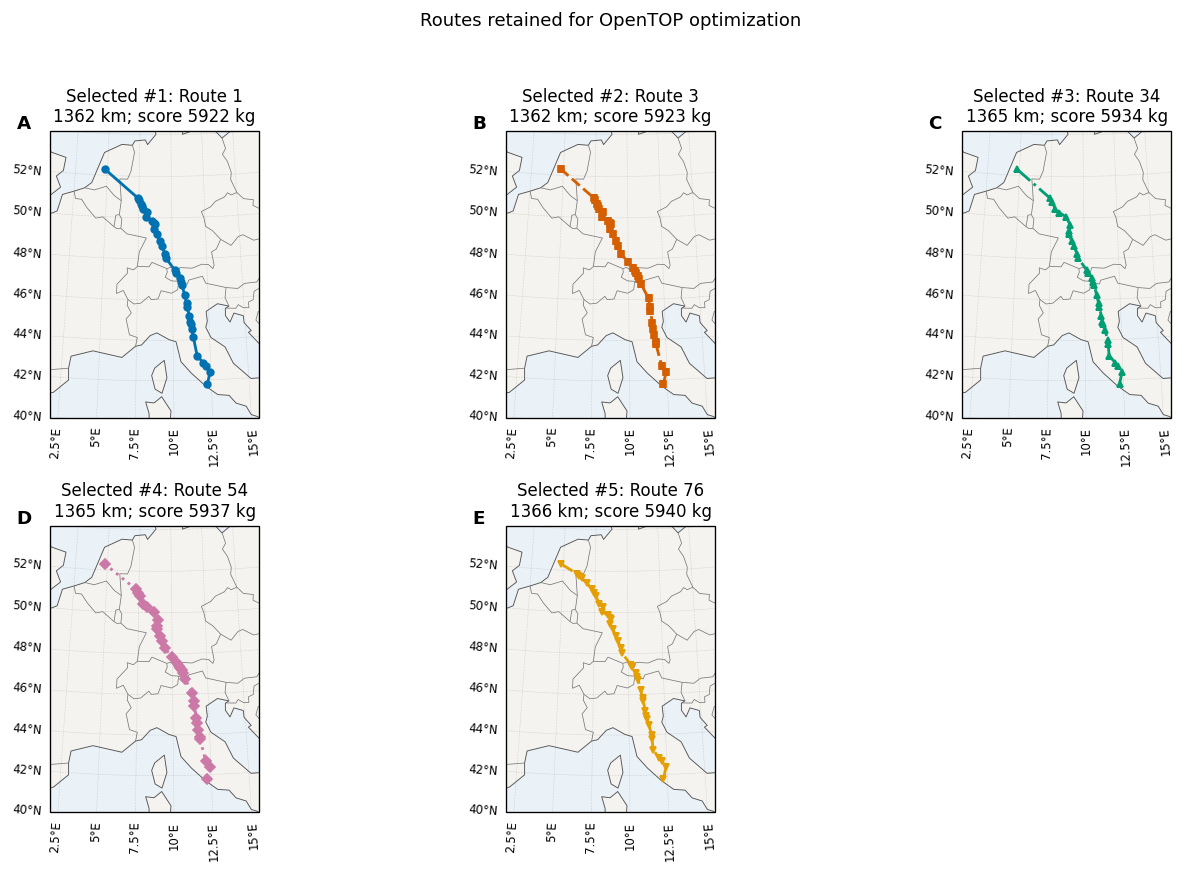

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7.0), subplot_kw={"projection": MAP_CRS})
axes = axes.ravel()
for index, (axis, route) in enumerate(zip(axes, candidates)):
    coordinates = [flight_network.nodes[node_id] for node_id in route.nodes]
    axis.plot(
        [node.longitude for node in coordinates],
        [node.latitude for node in coordinates],
        color=COLORS[index],
        linestyle=LINE_STYLES[index],
        marker=MARKERS[index],
        markersize=4,
        linewidth=1.7,
        transform=DATA_CRS,
    )
    finish_map(
        axis,
        (
            f"Selected #{index + 1}: {route_name(route).title()}\n"
            f"{route.distance_m / 1000:.0f} km; score {route.cost:.0f} kg"
        ),
    )
axes[-1].set_visible(False)
add_panel_labels(axes[:-1])
fig.suptitle("Routes retained for OpenTOP optimization", y=1.03)
fig.tight_layout()
plt.show()

### Visualize screening rank and diversity selection

Every ranked route remains visible, but only diversity-filtered NLP candidates are saturated. The bar chart reports all ten nominal-fuel scores directly. A grey route can outrank a colored route yet be rejected because it shares too much of an already retained path.

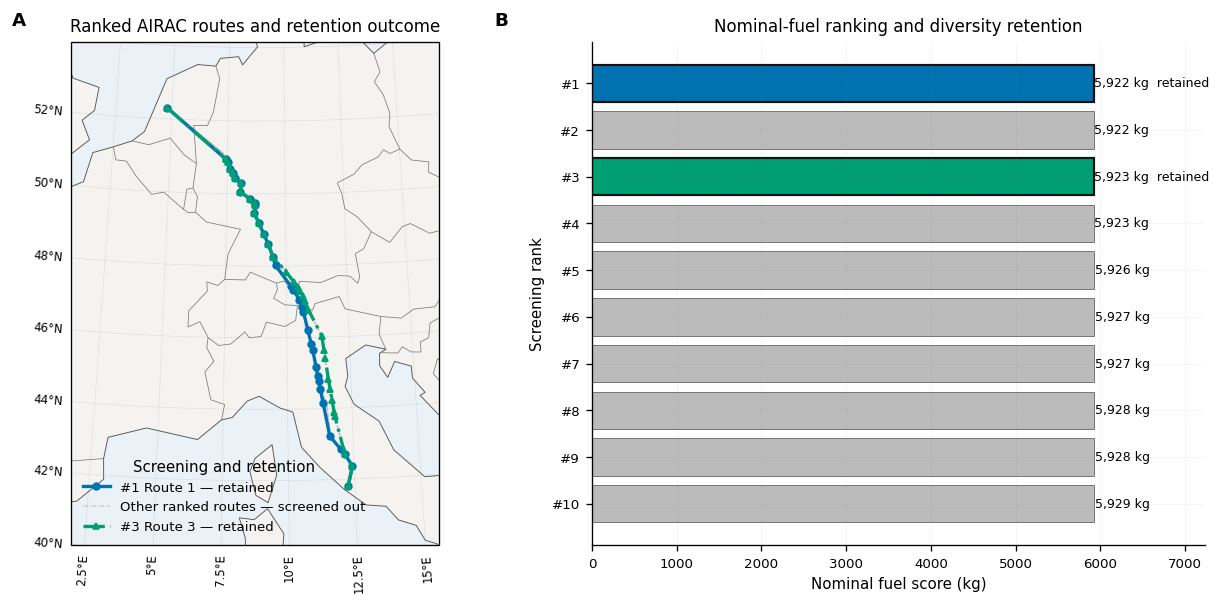

In [20]:
fig = plt.figure(figsize=(11, 5.1))
axes = np.array(
    [fig.add_subplot(1, 2, 1, projection=MAP_CRS), fig.add_subplot(1, 2, 2)]
)
rejected_label_used = False
for index, route in enumerate(ranked_routes):
    coordinates = [flight_network.nodes[node_id] for node_id in route.nodes]
    selected = route.edge_ids in selected_edge_sequences
    if selected:
        label = f"#{index + 1} {route_name(route).title()} — retained"
    elif not rejected_label_used:
        label = "Other ranked routes — screened out"
        rejected_label_used = True
    else:
        label = "_nolegend_"
    axes[0].plot(
        [node.longitude for node in coordinates],
        [node.latitude for node in coordinates],
        color=COLORS[index % len(COLORS)] if selected else "#999999",
        linestyle=LINE_STYLES[index % len(LINE_STYLES)],
        marker=MARKERS[index % len(MARKERS)] if selected else None,
        markersize=4,
        linewidth=2.0 if selected else 0.9,
        alpha=1.0 if selected else 0.38,
        label=label,
        transform=DATA_CRS,
        zorder=3 if selected else 2,
    )
axes[0].legend(title="Screening and retention", loc="lower left")
finish_map(axes[0], "Ranked AIRAC routes and retention outcome")

rank_labels = [f"#{row['rank']}" for _, row in ranked_table.iterrows()]
bar_colors = [
    COLORS[index % len(COLORS)] if row.selected_for_nlp else "#BBBBBB"
    for index, row in ranked_table.iterrows()
]
bars = axes[1].barh(
    rank_labels,
    ranked_table.nominal_fuel_score_kg,
    color=bar_colors,
    edgecolor="#666666",
    linewidth=0.5,
)
axes[1].invert_yaxis()
for bar, (_, row) in zip(bars, ranked_table.iterrows(), strict=True):
    if row.selected_for_nlp:
        bar.set_edgecolor("#111111")
        bar.set_linewidth(1.3)
    axes[1].text(
        row.nominal_fuel_score_kg + 8,
        bar.get_y() + bar.get_height() / 2,
        f"{row.nominal_fuel_score_kg:,.0f} kg"
        + ("  retained" if row.selected_for_nlp else ""),
        va="center",
        fontsize=7.5,
    )
axes[1].set_xlim(0, ranked_table.nominal_fuel_score_kg.max() * 1.22)
axes[1].set(
    title="Nominal-fuel ranking and diversity retention",
    xlabel="Nominal fuel score (kg)",
    ylabel="Screening rank",
)
finish_axis(axes[1])
add_panel_labels(axes)
fig.tight_layout()
plt.show()

## 7. Prepare a compact OpenTOP NLP handoff

The graph search retains every published segment, but constraining every nearly collinear graph node in the NLP adds little geometric information and can slow IPOPT substantially. OpenTOP therefore applies Ramer–Douglas–Peucker simplification in a local azimuthal-equidistant projection. A 15 km tolerance preserves meaningful route bends while removing redundant intermediate constraints on this 1,360 km corridor. The initial guess still follows the complete discrete polyline.

In [21]:
minimum_nodes = 20
nodes_per_leg = 1
waypoint_tolerance_m = 15_000.0
waypoint_simplification_tolerance_m = 15_000.0
handoff_rows = []
initial_guesses = {}
simplified_waypoints = {}
for route in candidates:
    waypoints = rad.simplify_route_waypoints(
        flight_network,
        route,
        tolerance_m=waypoint_simplification_tolerance_m,
    )
    nodes = max(minimum_nodes, nodes_per_leg * (len(waypoints) + 1))
    simplified_waypoints[route_name(route)] = waypoints
    initial_guesses[route_name(route)] = rad.route_initial_guess(
        flight_network,
        route,
        nodes=nodes,
        altitude_ft=32_000.0,
        mass_kg=62_000.0,
    )
    handoff_rows.append(
        {
            "route": route_name(route),
            "source_graph_edges": len(route.edges),
            "source_interior_points": len(route.nodes) - 2,
            "NLP_waypoints": len(waypoints),
            "collocation_intervals": nodes,
            "waypoint_tolerance_km": waypoint_tolerance_m / 1000,
        }
    )
display(pd.DataFrame(handoff_rows))
first_route = candidates[0]
first_waypoints = simplified_waypoints[route_name(first_route)]
display(
    pd.DataFrame(
        [
            {"order": index, "latitude_deg": lat, "longitude_deg": lon}
            for index, (lat, lon) in enumerate(first_waypoints, start=1)
        ]
    )
)

,route,source_graph_edges,source_interior_points,NLP_waypoints,collocation_intervals,waypoint_tolerance_km
0,route 1,34,33,7,20,15.0
1,route 3,33,32,8,20,15.0
2,route 34,31,30,7,20,15.0
3,route 54,30,29,8,20,15.0
4,route 76,38,37,7,20,15.0


,order,latitude_deg,longitude_deg
0,1,50.940278,7.442778
1,2,50.047500,8.078333
2,3,49.701111,8.726667
3,4,48.019167,9.563889
4,5,46.858056,10.618889
5,6,43.220278,11.608611
6,7,42.361389,12.432500


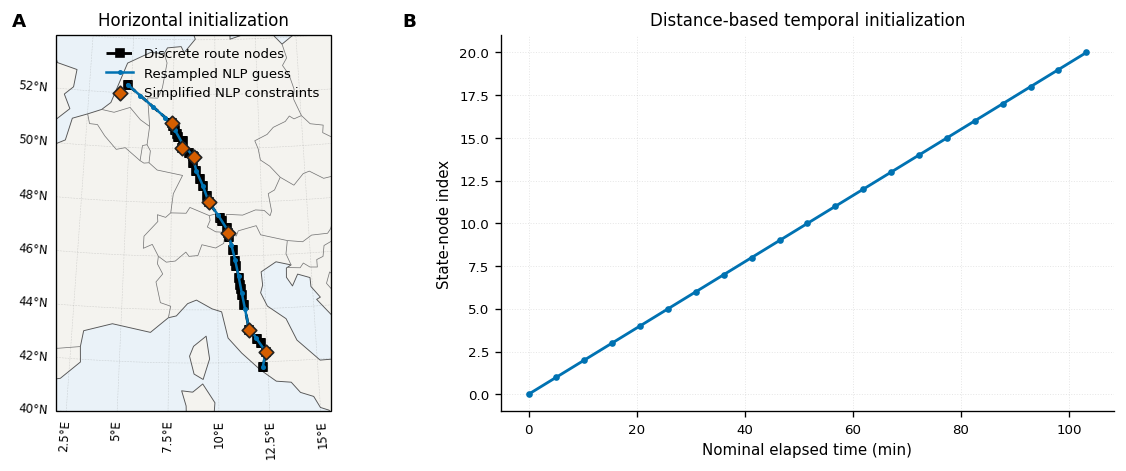

In [22]:
route = candidates[0]
guess = initial_guesses[route_name(route)]
discrete_nodes = [flight_network.nodes[node_id] for node_id in route.nodes]
fig = plt.figure(figsize=(10.5, 4.0))
axes = np.array(
    [fig.add_subplot(1, 2, 1, projection=MAP_CRS), fig.add_subplot(1, 2, 2)]
)
axes[0].plot(
    [node.longitude for node in discrete_nodes],
    [node.latitude for node in discrete_nodes],
    color="#000000",
    linestyle="--",
    marker="s",
    markersize=5,
    label="Discrete route nodes",
    transform=DATA_CRS,
)
axes[0].plot(
    guess.longitude,
    guess.latitude,
    color=COLORS[0],
    marker=".",
    linewidth=1.5,
    label="Resampled NLP guess",
    transform=DATA_CRS,
)
axes[0].scatter(
    [longitude for _, longitude in first_waypoints],
    [latitude for latitude, _ in first_waypoints],
    color=COLORS[1],
    edgecolor="#222222",
    marker="D",
    s=38,
    label="Simplified NLP constraints",
    transform=DATA_CRS,
    zorder=4,
)
axes[0].legend()
finish_map(axes[0], "Horizontal initialization")

axes[1].plot(
    guess.ts / 60,
    np.arange(len(guess)),
    color=COLORS[0],
    marker="o",
    markersize=3,
)
axes[1].set(
    title="Distance-based temporal initialization",
    xlabel="Nominal elapsed time (min)",
    ylabel="State-node index",
)
finish_axis(axes[1])
add_panel_labels(axes)
fig.tight_layout()
plt.show()

## 8. Inspect the continuous OpenTOP solutions

`top.optimize_routes` already gave every retained route a fresh `Cruise` optimizer and an explicit `fuel` objective—no cost index was used. Failed candidates remain in `route_result.optimized` with their status instead of terminating the batch. Here we expose the stored per-candidate outcomes and timings without running the solvers again.

In [23]:
optimized = list(route_result.optimized)
solve_seconds = list(route_result.solve_seconds)
for index, result in enumerate(optimized, start=1):
    print(
        f"Candidate {index} ({route_name(result.route)}): "
        f"success={result.success}, fuel={result.fuel_kg:.1f} kg, "
        f"time={solve_seconds[index - 1]:.1f} s, status={result.status}"
    )

Candidate 1 (route 1): success=True, fuel=4521.1 kg, time=6.8 s, status=Solve_Succeeded
Candidate 2 (route 3): success=True, fuel=4534.4 kg, time=7.7 s, status=Solve_Succeeded
Candidate 3 (route 34): success=True, fuel=4530.7 kg, time=9.2 s, status=Solve_Succeeded
Candidate 4 (route 54): success=True, fuel=4544.3 kg, time=11.0 s, status=Solve_Succeeded
Candidate 5 (route 76): success=True, fuel=4524.3 kg, time=13.4 s, status=Solve_Succeeded


In [24]:
optimization_table = pd.DataFrame(
    [
        {
            "candidate": index + 1,
            "optimized_fuel_kg": result.fuel_kg,
            "solve_time_s": solve_seconds[index],
            "success": result.success,
            "solver_status": result.status,
        }
        for index, result in enumerate(optimized)
    ]
)
comparison = candidate_table.merge(optimization_table, on="candidate")
best_fuel = comparison.loc[comparison.success, "optimized_fuel_kg"].min()
comparison["fuel_above_best_kg"] = comparison.optimized_fuel_kg - best_fuel
comparison["fuel_above_best_pct"] = 100 * (comparison.optimized_fuel_kg / best_fuel - 1)
display(
    comparison.sort_values(
        ["success", "optimized_fuel_kg"], ascending=[False, True]
    ).round(1)
)

,candidate,screening_rank,route,distance_km,distance_detour_pct,nominal_fuel_score_kg,shared_edges_with_best_pct,network_edges,optimized_fuel_kg,solve_time_s,success,solver_status,fuel_above_best_kg,fuel_above_best_pct
0,1,1,route 1,1362.0,0.0,5921.6,100.0,34,4521.1,6.8,True,Solve_Succeeded,0.0,0.0
4,5,76,route 76,1366.1,0.3,5939.8,68.4,38,4524.3,13.4,True,Solve_Succeeded,3.1,0.1
2,3,34,route 34,1364.9,0.2,5934.5,64.5,31,4530.7,9.2,True,Solve_Succeeded,9.6,0.2
1,2,3,route 3,1362.2,0.0,5922.6,51.5,33,4534.4,7.7,True,Solve_Succeeded,13.2,0.3
3,4,54,route 54,1365.4,0.3,5936.7,16.7,30,4544.3,11.0,True,Solve_Succeeded,23.1,0.5


## 9. Compare the continuous solutions

The final figure uses the same color, line style, and marker for a route in every panel. This redundant encoding keeps the comparison readable for color-vision deficiencies and in grayscale. These are deterministic optimization solutions, so uncertainty bars would not be meaningful.

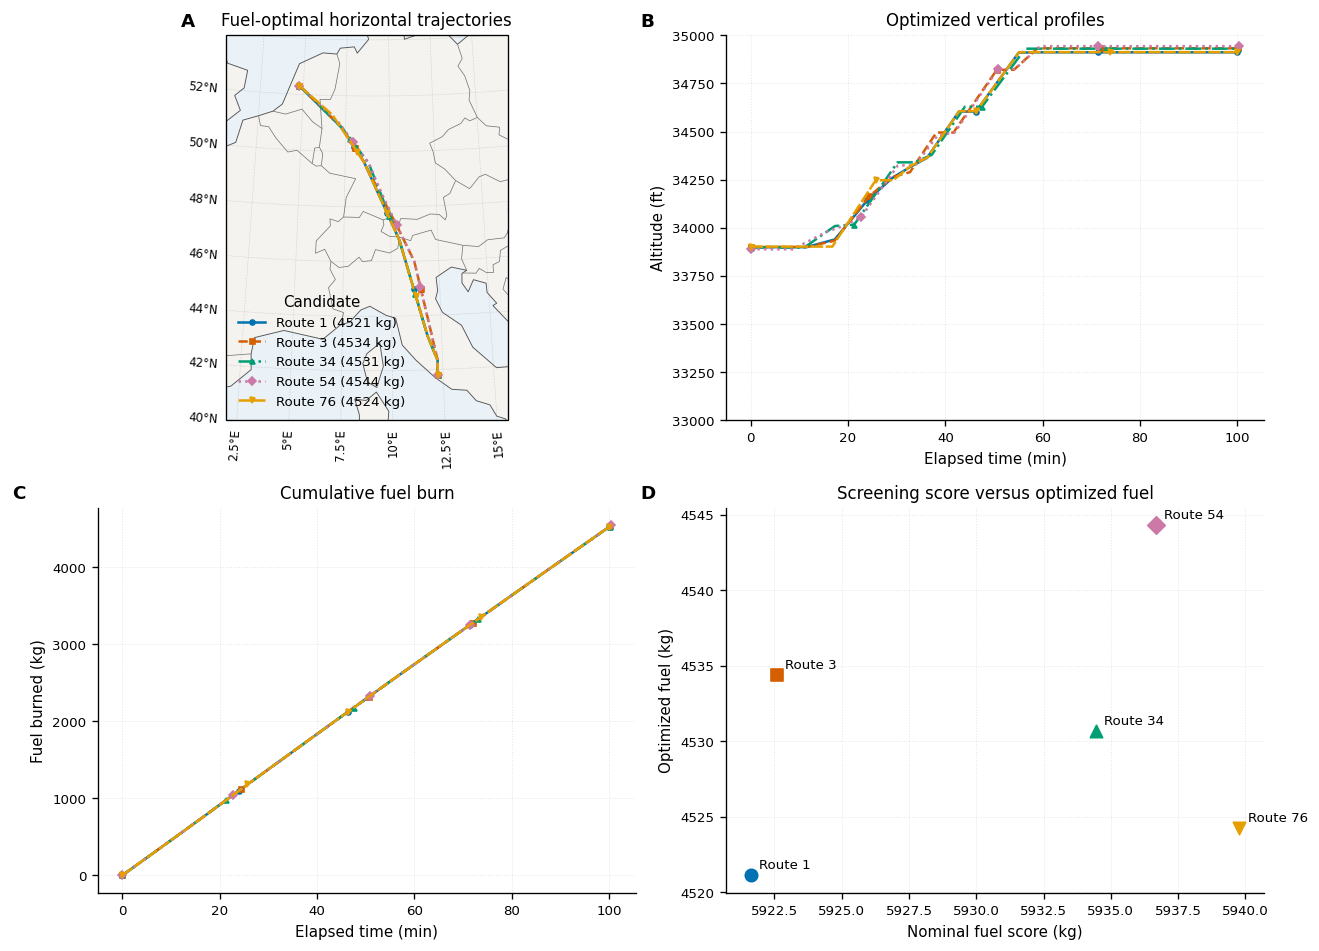

In [25]:
successful = [
    result for result in optimized if result.success and result.trajectory is not None
]
fig = plt.figure(figsize=(11, 8))
grid = fig.add_gridspec(2, 2)
axes = np.array(
    [
        [
            fig.add_subplot(grid[0, 0], projection=MAP_CRS),
            fig.add_subplot(grid[0, 1]),
        ],
        [fig.add_subplot(grid[1, 0]), fig.add_subplot(grid[1, 1])],
    ]
)

for index, result in enumerate(successful):
    trajectory = result.trajectory
    label = f"{route_name(result.route).title()} ({result.fuel_kg:.0f} kg)"
    style = {
        "color": COLORS[index],
        "linestyle": LINE_STYLES[index],
        "marker": MARKERS[index],
        "markevery": 5,
        "markersize": 3,
        "linewidth": 1.5,
    }
    axes[0, 0].plot(
        trajectory.longitude,
        trajectory.latitude,
        label=label,
        transform=DATA_CRS,
        **style,
    )
    axes[0, 1].plot(trajectory.ts / 60, trajectory.altitude, label=label, **style)
    cumulative_fuel = trajectory.mass.iloc[0] - trajectory.mass
    axes[1, 0].plot(trajectory.ts / 60, cumulative_fuel, label=label, **style)

axes[0, 1].set(
    title="Optimized vertical profiles",
    xlabel="Elapsed time (min)",
    ylabel="Altitude (ft)",
)
axes[0, 1].ticklabel_format(axis="y", style="plain", useOffset=False)
axes[0, 1].set_ylim(33_000, 35_000)
axes[1, 0].set(
    title="Cumulative fuel burn",
    xlabel="Elapsed time (min)",
    ylabel="Fuel burned (kg)",
)

for index, row in comparison.iterrows():
    axes[1, 1].scatter(
        row.nominal_fuel_score_kg,
        row.optimized_fuel_kg,
        color=COLORS[index],
        marker=MARKERS[index],
        s=55,
        label=row.route.title(),
    )
    axes[1, 1].annotate(
        row.route.title(),
        (row.nominal_fuel_score_kg, row.optimized_fuel_kg),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
    )
axes[1, 1].set(
    title="Screening score versus optimized fuel",
    xlabel="Nominal fuel score (kg)",
    ylabel="Optimized fuel (kg)",
)

axes[0, 0].legend(title="Candidate")
finish_map(axes[0, 0], "Fuel-optimal horizontal trajectories")
for axis in (axes[0, 1], axes[1, 0], axes[1, 1]):
    finish_axis(axis)
add_panel_labels(axes)
fig.tight_layout()
plt.show()

In [26]:
best = min(successful, key=lambda result: result.fuel_kg)
pd.DataFrame(
    [
        {
            "selected_route": route_name(best.route),
            "optimized_fuel_kg": best.fuel_kg,
            "distance_km": best.route.distance_m / 1000,
            "solver_status": best.status,
            "waypoint_order_validated": best.success,
        }
    ]
).round(1)

,selected_route,optimized_fuel_kg,distance_km,solver_status,waypoint_order_validated
0,route 1,4521.1,1362.0,Solve_Succeeded,True


### Final selected route

After continuous optimization, the selected route is shown against the complete available network and the other optimized candidates. The comparison panel reports fuel above the best solution, so the zero baseline has a direct operational meaning.

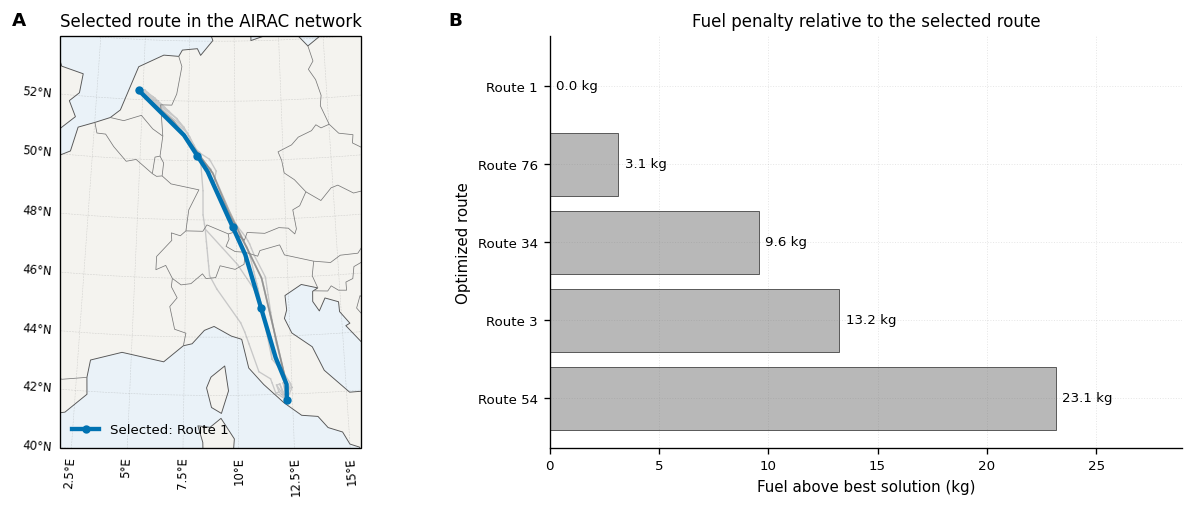

In [27]:
best_name = route_name(best.route)
best_index = [route_name(route) for route in candidates].index(best_name)
fig = plt.figure(figsize=(11, 4.3))
axes = np.array(
    [fig.add_subplot(1, 2, 1, projection=MAP_CRS), fig.add_subplot(1, 2, 2)]
)

for edge in flight_network.edges.values():
    source = flight_network.nodes[edge.source]
    target = flight_network.nodes[edge.target]
    axes[0].plot(
        [source.longitude, target.longitude],
        [source.latitude, target.latitude],
        color="#C8C8C8",
        linewidth=0.8,
        transform=DATA_CRS,
        zorder=1,
    )
for result in successful:
    if route_name(result.route) == best_name:
        continue
    axes[0].plot(
        result.trajectory.longitude,
        result.trajectory.latitude,
        color="#888888",
        linewidth=1.0,
        alpha=0.65,
        transform=DATA_CRS,
        zorder=2,
    )
axes[0].plot(
    best.trajectory.longitude,
    best.trajectory.latitude,
    color=COLORS[best_index],
    linewidth=2.6,
    marker=MARKERS[best_index],
    markevery=5,
    markersize=4,
    label=f"Selected: {best_name.title()}",
    transform=DATA_CRS,
    zorder=4,
)
axes[0].legend(loc="lower left")
finish_map(axes[0], "Selected route in the AIRAC network")

fuel_comparison = comparison.sort_values("optimized_fuel_kg").reset_index(drop=True)
bar_colors = [
    COLORS[best_index] if route == best_name else "#B8B8B8"
    for route in fuel_comparison.route
]
bars = axes[1].barh(
    fuel_comparison.route.str.title(),
    fuel_comparison.fuel_above_best_kg,
    color=bar_colors,
    edgecolor="#444444",
    linewidth=0.5,
)
axes[1].invert_yaxis()
axes[1].bar_label(bars, fmt="%.1f kg", padding=4, fontsize=8)
axes[1].set(
    title="Fuel penalty relative to the selected route",
    xlabel="Fuel above best solution (kg)",
    ylabel="Optimized route",
)
axes[1].set_xlim(0, fuel_comparison.fuel_above_best_kg.max() * 1.25)
finish_axis(axes[1])
add_panel_labels(axes)
fig.tight_layout()
plt.show()

## Interpretation and production use

This source-derived case demonstrates the intended separation of responsibilities. The graph stage searches actual AIRAC 2406 waypoint/segment topology and reduces it to a small, diverse candidate set. The nominal fuel score is only a cheap screening approximation; fuel from the continuous OpenTOP solve is the final decision metric.

For larger route sets, first use graph screening to limit the options passed to `top.optimize_routes`. A future `RouteOptimizationConfig` extension can add coarse-to-fine refinement without introducing another optimization entry point. Process-level parallelism can likewise remain an implementation detail behind the same API.

The nearly level profiles are a consequence of this example's cruise-only fuel optimization, not a RAD requirement. The FL350 context filters the route network; it is not an altitude equality constraint. The generic company-route example uses `CompleteFlight` when climb and descent should be optimized as well.

The limitations remain explicit. This development snapshot fixes one AIRAC cycle, VST layer, city pair, and odd-level orientation. Operational planning still requires the complete applicable network plus authoritative AWK/FLC2, calendar, procedure, and current-cycle conformance checks. The existing `Cruise`, `CompleteFlight`, `Climb`, and `Descent` APIs remain unchanged.